<a href="https://colab.research.google.com/github/TyreeRebe/Fake-Review-Model-Detection-a-Model-Comparison/blob/main/Another_copy_of_yay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Bring the libraries over
import pandas as pd
import numpy as np

# NLP libraries
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Feature engineering
from sklearn.feature_extraction.text import TfidfVectorizer

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Sentiment Analysis
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Transformer model
!pip install transformers
from transformers import pipeline

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
#Load the Dataset
df=pd.read_excel("Data- Sentiment Analysis and Fake Review Detection in E-commerce.xlsx")

In [ ]:
#Look at the Data
df.head()
df.info()
df.shape
df.columns
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001 entries, 0 to 10000
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10001 non-null  object 
 1   brand                 10001 non-null  object 
 2   categories            10001 non-null  object 
 3   dateAdded             10001 non-null  object 
 4   dateUpdated           10001 non-null  object 
 5   ean                   6866 non-null   float64
 6   keys                  10001 non-null  object 
 7   manufacturer          10001 non-null  object 
 8   manufacturerNumber    9983 non-null   object 
 9   name                  10001 non-null  object 
 10  reviews.date          9987 non-null   object 
 11  reviews.dateAdded     10001 non-null  object 
 12  reviews.dateSeen      10001 non-null  object 
 13  reviews.didPurchase   3637 non-null   float64
 14  reviews.doRecommend   9442 non-null   float64
 15  reviews.id         

,0
id,0
brand,0
categories,0
dateAdded,0
dateUpdated,0
ean,3135
keys,0
manufacturer,0
manufacturerNumber,18
name,0


Get rid of the missing data.

In [ ]:
#CLEAN THE DATA!
df_clean=df.copy()
df_clean = df_clean.dropna(subset=['reviews.text'])
df_clean['reviews.title']= df_clean ['reviews.title'].fillna('Unknown')
df_clean['reviews.username']= df_clean ['reviews.username'].fillna('Unknown')
df_clean["reviews.userCity"]= df_clean ['reviews.userCity'].fillna('Unknown')
df_clean["reviews.didPurchase"]= df_clean ['reviews.didPurchase'].fillna('Unknown')
df_clean["reviews.numHelpful"]= df_clean ['reviews.numHelpful'].fillna('Unknown')
df_clean["reviews.userProvince"]= df_clean ['reviews.userProvince'].fillna('Unknown')
df_clean["reviews.date"]= df_clean ['reviews.date'].fillna('Unknown')
df_clean["manufacturerNumber"]= df_clean ['manufacturerNumber'].fillna('Unknown')
df_clean["reviews.doRecommend"]= df_clean ['reviews.doRecommend'].fillna('Unknown')
df_clean["reviews.id"]= df_clean ['reviews.id'].fillna('Unknown')
df_clean.isnull().sum()

,0
id,0
brand,0
categories,0
dateAdded,0
dateUpdated,0
ean,3135
keys,0
manufacturer,0
manufacturerNumber,0
name,0


I purposely left the EAN number as is.The EAN's value is a Label for the entire dataset, if I change this number it would distort the AVERAGE and the distribution VARIANCE value of the dataset and ruin my information.

In [ ]:
#WOULD you look at this data
df_clean["reviews.date"]=pd.to_datetime(df_clean["reviews.date"], errors="coerce")
df_clean

#Time Based analysis :) let's take a look at those TRENDS!
df_date= df_clean.dropna(subset=["reviews.date"]).copy()
df_date

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,upc
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.025370e+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,Unknown,0.0,5,https://redsky.target.com/groot-domain-api/v1/...,i love this album. it's very good. more to the...,Just Awesome,Los Angeles,Unknown,Joshua,6.025370e+11
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,7.341600e+10,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,Unknown,5,https://www.walmart.com/reviews/product/29775278,Good flavor. This review was collected as part...,Good,Unknown,Unknown,Dorothy W,7.341600e+10
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,7.341600e+10,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,100209113.0,Unknown,5,https://www.walmart.com/reviews/product/29775278,Good flavor.,Good,Unknown,Unknown,Dorothy W,7.341600e+10
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,6.798193e+10,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,113026909.0,Unknown,1,https://www.walmart.com/reviews/product/43383370,I read through the reviews on here before look...,Disappointed,Unknown,Unknown,Rebecca,6.798193e+10
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,6.798193e+10,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,171267657.0,Unknown,1,https://www.walmart.com/reviews/product/43383370,My husband bought this gel for us. The gel cau...,Irritation,Unknown,Unknown,Walker557,6.798193e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",2015-09-11T18:17:13Z,2018-02-05T08:35:02Z,4.460002e+10,"clorox/12992356,044600015996,cloroxdisinfectin...",Clorox,12992356,Clorox Disinfecting Wipes Value Pack Scented 1...,...,68199373.0,Unknown,5,https://www.walmart.com/reviews/product/148983...,Their products clean well. They are a reliable...,Trusted brand,Unknown,Unknown,hsw88,4.460002e+10
9997,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",2015-09-11T18:17:13Z,2018-02-05T08:35:02Z,4.460002e+10,"clorox/12992356,044600015996,cloroxdisinfectin...",Clorox,12992356,Clorox Disinfecting Wipes Value Pack Scented 1...,...,70171201.0,Unknown,5,https://www.walmart.com/reviews/product/148983...,absolutely LOVE the Clorox wipes. makes life e...,wipse,Unknown,Unknown,toriashli90,4.460002e+10
9998,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",2015-09-11T18:17:13Z,2018-02-05T08:35:02Z,4.460002e+10,"clorox/12992356,044600015996,cloroxdisinfectin...",Clorox,12992356,Clorox Disinfecting Wipes Value Pack Scented 1...,...,70595659.0,Unknown,5,https://www.walmart.com/reviews/product/148983...,Love to use in mostly in the bathroom or kitch...,Love them!,Unknown,Unknown,Sher017,4.460002e+10
9999,AVpf3VOfilAPnD_xjpun,Clorox,"Household Essentials,Cleaning Supplies,Kitchen...",2015-09-11T18:17:13Z,2018-02-05T08:35:02Z,4.460002e+10,"clorox/12992356,044600015996,cloroxdisinfectin...",Clorox,12992356,Clorox Disinfecting Wipes Value Pack Scented 1...,...,69683513.0,Unknown,5,https://www.walmart.c

In [ ]:
#Text Preprocessing pipeline
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()

def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'\[.*?\]', '', text)
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  text = re.sub(r'<.*?>+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\n', '', text)
  text = re.sub(r'\w*\d\w*', '', text)
  words = text.split()
  words = [w for w in words if w not in stop_words]
  words = [lemmatizer.lemmatize(word, pos='a') for word in words]
  words = [lemmatizer.lemmatize(word, pos='v') for word in words]
  return " ".join(words)

df["cleaned_review"] = df["reviews.text"].apply(clean_text)
df[['reviews.text', 'cleaned_review']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,reviews.text,cleaned_review
0,i love this album. it's very good. more to the...,love album good hip hop side current pop sound...
1,Good flavor. This review was collected as part...,good flavor review collect part promotion
2,Good flavor.,good flavor
3,I read through the reviews on here before look...,read review look buy one couple lubricants ult...
4,My husband bought this gel for us. The gel cau...,husband buy gel us gel cause irritation felt l...


Beaks down the phrases/sentences into cleaner phrases. all lowercase, no hyperlinks,no numbers,no punctuation, split the words, remove stopwords and HTML tags, root words only,and it puts word back into a sentence.

In [ ]:
from numpy import vectorize
#Build Sentiment Model
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df["cleaned_review"])

df["fake_review"]=df["cleaned_review"].apply(
    lambda x:1 if TextBlob(x).sentiment.polarity > 0 else 0.0
)

y = df["fake_review"]

Learns vocabulary and converts it into a row of numbers.

In [ ]:
print (df.columns)

Index(['id', 'brand', 'categories', 'dateAdded', 'dateUpdated', 'ean', 'keys',
       'manufacturer', 'manufacturerNumber', 'name', 'reviews.date',
       'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase',
       'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful',
       'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'upc',
       'cleaned_review', 'fake_review'],
      dtype='object')


In [ ]:
#Use Review Length and Sentiment for Anomaly Detection
df_clean["review_length"]=(
    df_clean["reviews.text"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
    )
#TextBlob
from textblob import TextBlob
df_clean["sentiment_polarity"]=(
    df_clean["reviews.text"]
    .fillna("")
    .astype(str)
    .apply(lambda x: TextBlob(x).sentiment.polarity)
)
#polarity goes from -1,0, to 1. 1 is positive
#delete repeats
df_clean["repetitive_review"] =(
    df_clean["reviews.text"]
    .fillna("")
    .astype(str)
    .duplicated(keep=False)
)
#1=same review, 0=a single value unrepeated
#strange reviews
#very short reviews
df_clean["short_review"]=(
  df_clean["review_length"]<10
).astype(int)
#very negative or positive reviews sentiment
df_clean["extreme_sentiment"]=(
   df_clean["sentiment_polarity"].abs()>=0.80
).astype(int)

#low helpful votes
df_clean["low_helpful"] = (
    pd.to_numeric(df_clean["reviews.numHelpful"], errors="coerce")
    .fillna(-1)
    < 5
).astype(int)
#suspicisous score
df_clean["suspicion_score"]=(
    +df_clean["short_review"]
    +df_clean["low_helpful"]
    +df_clean["repetitive_review"]
    +df_clean["extreme_sentiment"]
)
#fake review proxy
df_clean["fake_review_proxy"]=(
    df_clean["suspicion_score"]>0
).astype(int)

# Add the 'fake_review' column to df_clean based on 'reviews.numHelpful'
# This aligns with the definition used in df_model, but applied to the df_clean DataFrame
df_clean["fake_review"] = (
    df_clean["reviews.numHelpful"] == 0
).astype(int)

#
print(df_clean["fake_review"].value_counts())

print(
    df_clean["fake_review"]
    .value_counts(normalize=True)
    *100
)

#see all the info
df_clean[
    ["reviews.text","review_length","sentiment_polarity","repetitive_review","short_review","low_helpful","extreme_sentiment","suspicion_score","fake_review_proxy","fake_review"]
].head(20)


fake_review
0    6200
1    3798
Name: count, dtype: int64
fake_review
0    62.012402
1    37.987598
Name: proportion, dtype: float64


,reviews.text,review_length,sentiment_polarity,repetitive_review,short_review,low_helpful,extreme_sentiment,suspicion_score,fake_review_proxy,fake_review
0,i love this album. it's very good. more to the...,41,0.222857,False,0,1,0,1,1,1
1,Good flavor. This review was collected as part...,11,0.700000,False,0,1,0,1,1,0
2,Good flavor.,2,0.700000,True,1,1,0,3,1,0
3,I read through the reviews on here before look...,124,-0.040109,False,0,1,0,1,1,0
4,My husband bought this gel for us. The gel cau...,25,0.000000,False,0,1,0,1,1,0
5,My boyfriend and I bought this to spice things...,52,-0.012500,False,0,1,0,1,1,0
6,Bought this earlier today and was excited to c...,47,-0.020312,False,0,1,0,1,1,0
7,I bought this product for my husband and I to ...,48,-0.075000,False,0,1,0,1,1,0
8,My husband and I bought this for some extra fu...,35,-0.087500,False,0,1,0,1,1,0
9,Got as a surprise for my husband there is noth...,37,0.071429,False,0,1,0,1,1,0


In [ ]:
df_clean["fake_review"]=(
    ((df_clean["review_length"]<5) &
    (df_clean["sentiment_polarity"].abs()>=0.80)) |

    ((df_clean["review_length"]<5)&
    (df_clean["repetitive_review"]==1)) |

    ((df_clean["repetitive_review"]==1)&
    (df_clean["low_helpful"]==1))
).astype(int)
print(df_clean["fake_review"].value_counts())
print(
    df_clean["fake_review"]
    .value_counts(normalize=True)
    *100
)

fake_review
0    9536
1     462
Name: count, dtype: int64
fake_review
0    95.379076
1     4.620924
Name: proportion, dtype: float64


95.3% real reviews between the legth of the review and sentiment.4.6% are probably fake reiews.

/tmp/ipykernel_14113/23585576.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["sentiment_polarity"]


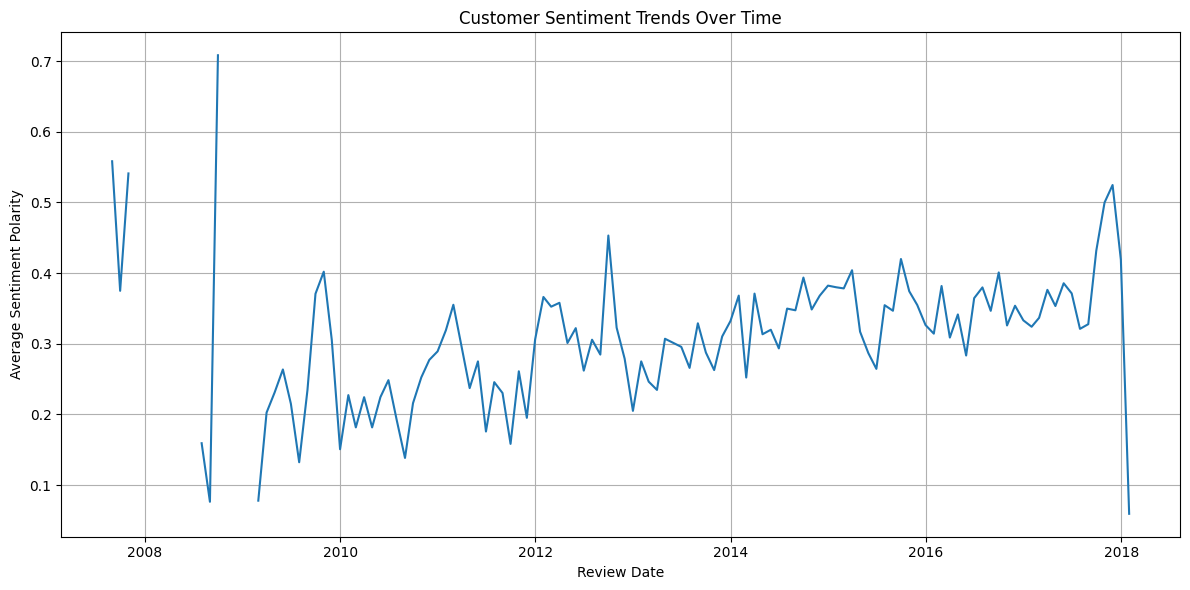

In [ ]:
#See thesentiment trends over time
from textblob import TextBlob
import matplotlib.pyplot as plt

df["reviews.date"]=pd.to_datetime(
    df["reviews.date"],
    errors="coerce",
    utc=True
)
df["sentiment_polarity"]=(
    df["reviews.text"]
    .fillna("")
    .astype(str)
    .apply(lambda x: TextBlob(x).sentiment.polarity)
)
#remove the rows with missing info
sentiment_df=df.dropna(subset=["reviews.date"]).copy()
#Group by the month for the average sentiment
monthly_sentiment=(
    sentiment_df
    .set_index("reviews.date")
    .resample("M")["sentiment_polarity"]
    .mean()
)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sentiment.index, monthly_sentiment.values)
plt.title("Customer Sentiment Trends Over Time")
plt.xlabel("Review Date")
plt.ylabel("Average Sentiment Polarity")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#USE Helpful to make a fake review proxy. Let's find SEE
df_clean ["helpful_missing"]= (
    df_clean["reviews.numHelpful"].astype(str) + "/" + df_clean["reviews.numHelpful"].astype(str)

)
df_clean["reviews.numHelpful"]=(
    pd.to_numeric(df_clean["reviews.numHelpful"], errors="coerce").fillna(0).astype(int)
)
#Make fake review labels when the helful vote information is there
df_model =df_clean.dropna(subset=["reviews.numHelpful"]).copy()

df_model["fake_review"]= (
    df_model["reviews.numHelpful"] == 0
).astype(int)
df_model.head()

,id,brand,categories,dateAdded,dateUpdated,ean,keys,manufacturer,manufacturerNumber,name,...,review_length,sentiment_polarity,repetitive_review,short_review,extreme_sentiment,low_helpful,suspicion_score,fake_review_proxy,fake_review,helpful_missing
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Mo...",2017-07-25T00:52:42Z,2018-02-05T08:36:58Z,6.025370e+11,"602537205981,universalmusic/14331328,universal...",Universal Music Group / Cash Money,14331328,Pink Friday: Roman Reloaded Re-Up (w/dvd),...,41,0.222857,False,0,0,1,1,1,1,0.0/0.0
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,7.341600e+10,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,11,0.700000,False,0,0,1,1,1,1,Unknown/Unknown
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Co...",2017-07-25T05:16:03Z,2018-02-05T11:27:45Z,7.341600e+10,lundbergorganiccinnamontoastricecakes/b000fvzw...,Lundberg,574764,Lundberg Organic Cinnamon Toast Rice Cakes,...,2,0.700000,True,1,0,1,3,1,1,Unknown/Unknown
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,6.798193e+10,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,124,-0.040109,False,0,0,1,1,1,1,Unknown/Unknown
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Sperm...",2017-07-25T16:26:19Z,2018-02-05T11:25:51Z,6.798193e+10,"kylovesensualitypleasuregel/b00u2whx8s,0679819...",K-Y,67981934427,K-Y Love Sensuality Pleasure Gel,...,25,0.000000,False,0,0,1,1,1,1,Unknown/Unknown


In [ ]:
#Helpful missing column data type check
print(df_model["helpful_missing"].dtype)

#CHeck unique values
print(df_model["helpful_missing"].unique())


object
['0.0/0.0' 'Unknown/Unknown' '1.0/1.0' '3.0/3.0' '6.0/6.0' '4.0/4.0'
 '18.0/18.0' '8.0/8.0' '2.0/2.0' '5.0/5.0' '7.0/7.0' '39.0/39.0'
 '22.0/22.0' '52.0/52.0' '12.0/12.0' '9.0/9.0' '16.0/16.0' '11.0/11.0'
 '10.0/10.0' '34.0/34.0' '14.0/14.0' '56.0/56.0' '21.0/21.0' '13.0/13.0'
 '46.0/46.0' '35.0/35.0' '23.0/23.0' '20.0/20.0' '47.0/47.0' '33.0/33.0'
 '45.0/45.0' '41.0/41.0' '27.0/27.0' '28.0/28.0' '96.0/96.0' '26.0/26.0'
 '141.0/141.0' '19.0/19.0' '17.0/17.0']


In [ ]:
#Start over with the helpful missing, becuase that first run makes no sense.
df_model["helpful_missing"]= (
    df_model["reviews.numHelpful"]
    .isna()
    .astype(int)
)
print(df_model["helpful_missing"].unique())
print(df_model["helpful_missing"].dtype)
print(df_model["helpful_missing"].value_counts())

[0]
int64
helpful_missing
0    9998
Name: count, dtype: int64


That's almost the entire dataset. There's no way this is correct either... 😖

In [ ]:
#Let's look at the columns real quick...
print(df["reviews.numHelpful"].isna().sum())
print(df["reviews.numHelpful"].head())
print(df.shape)

5757
0    0.0
1    NaN
2    NaN
3    NaN
4    NaN
Name: reviews.numHelpful, dtype: float64
(10001, 28)


5,757 are missing helpful vote values, but it still isn't showing if the helpful votes are there.

In [ ]:
#Let's try this AGAIN!
df_model=df.dropna(subset=["reviews.numHelpful"]).copy()

#make sure the model is numeric
df_model["reviews.numHelpful"]=pd.to_numeric(df_model["reviews.numHelpful"], errors="coerce")

#make the other target because the real target is just TOO much.
df_model["fake_review"]= (df_model["reviews.numHelpful"] == 0).astype(int)
df_model.head()

print(df_model["reviews.numHelpful"].isna().sum())
print(df_model.shape)

0
(4244, 28)


There are 4,244 rows of reviews with true values in the reviews.numHelpful column.

In [ ]:
df_model["helpful_missing"] = df_model["reviews.numHelpful"].isna().astype(int)
df_model[["reviews.numHelpful","helpful_missing","fake_review"]].head(10)

,reviews.numHelpful,helpful_missing,fake_review
0,0.0,0,1
30,1.0,0,0
35,0.0,0,1
36,3.0,0,0
37,1.0,0,0
38,6.0,0,0
39,1.0,0,0
40,0.0,0,1
43,0.0,0,1
46,1.0,0,0


Removed the values of helpful_missing, so that's why its 0.

In [ ]:
#NOW let's see exactly how many real vs fake reviews we have
print(df_model["fake_review"].value_counts())
print(df_model["fake_review"].value_counts(normalize=True)*100)

fake_review
1    3798
0     446
Name: count, dtype: int64
fake_review
1    89.491046
0    10.508954
Name: proportion, dtype: float64


convert the proportion into a percentage by multiplying by 100. The fake review dataset is not balanced. About 89.5% are rea; reviews and 10.5% are probably fake reviews. Not good, this shows a limitation/anomaly.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

model=LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.50      0.89      0.64       227
         1.0       0.98      0.89      0.93      1774

    accuracy                           0.89      2001
   macro avg       0.74      0.89      0.79      2001
weighted avg       0.93      0.89      0.90      2001

0.8865567216391804


THe F1 score of .91 shows that the model performed, but F1 score of .68 is a reflection of there being a limitation/anomaly with the data. The model shows the fake reviews, but isn't as a great as showing the real reviews.

In [ ]:
#Implement Anomoly Detection Isolation Forest
from sklearn.ensemble import IsolationForest
#Build The isolation Forest
iso_model = IsolationForest(
    contamination=0.1, #Assume 10% anomaly, random_state=42
)
#Fit and predict
iso_predictions=iso_model.fit_predict(X)

#Convert predictions
#-1 =anomaly
#1= normale
df["Isolation_anomaly"]=(
  iso_predictions==-1
).astype(int)
print(df["Isolation_anomaly"].value_counts())

Isolation_anomaly
0    9001
1    1000
Name: count, dtype: int64


Confirms that about 10% of the reviews are an anomaly. The reviews could be fake or just missing.

In [ ]:
#Let's take a deeper look
comparison=pd.crosstab(
    df_model["fake_review"],
    df.loc[df_model.index,"Isolation_anomaly"]
)
print(comparison)

Isolation_anomaly     0    1
fake_review                 
0                   359   87
1                  3627  171


Isolation Forest removed the helpful votes. Now we're left with 3,552 normal fake reviews and 246 anomalies. Because the ISolation Forest detects small proportions, unlike the proxy fake review, which relies on the number of helpful votes. LINE 42 agrees with this line of code, but the results vary slightly because of these difference in how the models run.

In [ ]:
#Exploratory STatistical Summaries
#ratings
print("Ratings Summary Statistics")
print(df["reviews.rating"].describe())

Ratings Summary Statistics
count    10001.000000
mean         4.480752
std          0.852088
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: reviews.rating, dtype: float64


Most of the ratings are positive 4.48 average rating is pretty high.

In [ ]:
#Exploratory Statistical Summaries
#Helpful Votes
print("Helpful Votes Summary Statistics")
print(df["reviews.numHelpful"].describe())

Helpful Votes Summary Statistics
count    4244.000000
mean        0.474552
std         3.732331
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       141.000000
Name: reviews.numHelpful, dtype: float64


THis shows why the proxy review was imbalanced too, most of the helpful vote values had zero.

In [ ]:
#Exploratory Statistical SUmmaries
#Purchasing Behavior
print("Purchasing Behavior Summary Statistics")
print(df["reviews.didPurchase"].describe())

Purchasing Behavior Summary Statistics
count    3637.000000
mean        0.136651
std         0.343526
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: reviews.didPurchase, dtype: float64


The 3,637 reviews with purchase information, only 13.67% are verified purchases 100-13.67%= 86.33%. Therefore, 86.33% are not verified purchases. This may contribute the anamoly mentioned earlier within the data.

In [ ]:
#Identify the most/least reviewed brands using aggregation
brand_reviews=(
    df_clean.groupby("brand")["reviews.text"]
    .count()
    .sort_values(ascending=False)
)
print("Top 10 Most Reviewed Brands")
print(brand_reviews.head(10))
print("Top 10 Least Reviewed Brands")
print(brand_reviews.tail(10))

Top 10 Most Reviewed Brands
brand
Clorox                  3413
Sony Pictures            847
FOX                      757
Summit Entertainment     673
Universal Home Video     668
Olay                     651
Warner Bros.             454
Hoover                   372
Pendaflex                367
Windex                   348
Name: reviews.text, dtype: int64
Top 10 Least Reviewed Brands
brand
Herr's                            1
Hortense B. Hewitt                1
No Brand                          1
Jake And The Neverland Pirates    1
SLOAN VALVE COMPANY               1
Pearhead                          1
Progresso                         1
Udi's                             1
Universal Music                   1
iStarUSA                          1
Name: reviews.text, dtype: int64


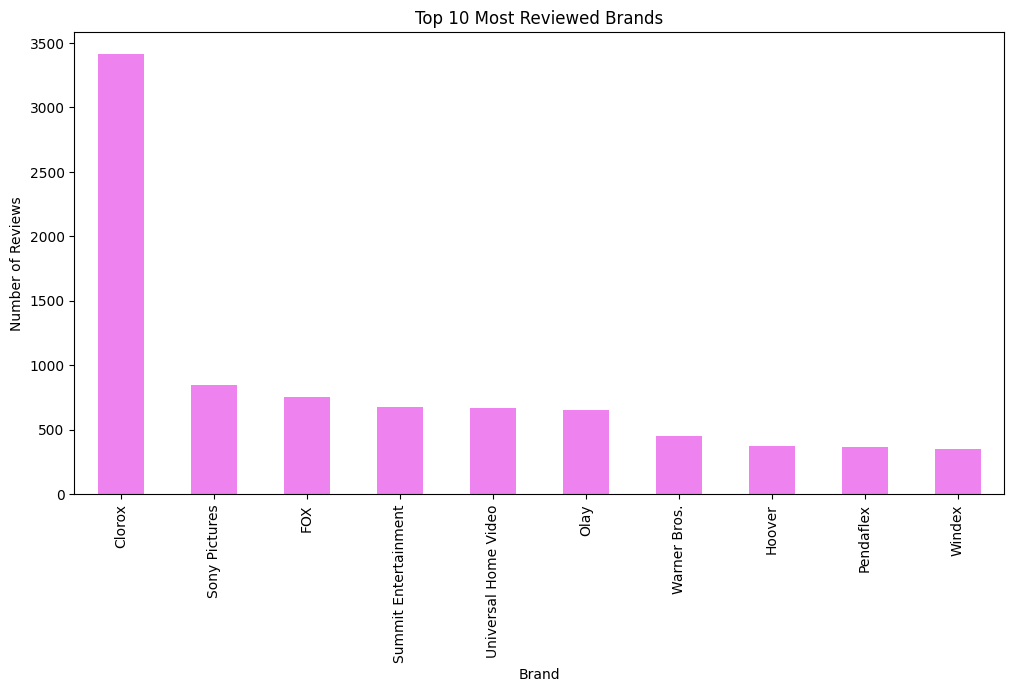

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
brand_reviews.head(10).plot(kind="bar",color="violet")
plt.title("Top 10 Most Reviewed Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Reviews")

plt.show()

CLorox got the Most customer reviews. Companies such as Warner Bros, Hoover, Pendaflex, and Windows recieved low customer review engagment.

In [ ]:
#Visualize the distribution of ratings across categories
#Extract the first category
df_clean["first_category"]=df_clean["categories"].str.split(",").str[0]
#AVerage rating by category
category_ratings=(
    df_clean.groupby("first_category")["reviews.rating"]
  .mean()
.sort_values(ascending=False)
)
print("Average Rating by Category")
print(category_ratings)

Average Rating by Category
first_category
Home Improvement            5.000000
Furniture                   5.000000
Party Supplies              5.000000
Auto & Tires                4.916667
Food & Beverage             4.697674
Health                      4.692308
Movies                      4.563654
Household Essentials        4.512908
Movies & TV Shows           4.467832
Personal Care               4.459971
Household Chemicals         4.344828
Food                        4.327411
Home                        4.326923
Sports & Outdoors           4.200000
School & Office Supplies    4.166213
Gift Finder                 4.000000
Pro Audio                   3.000000
Holiday Shop                2.000000
Name: reviews.rating, dtype: float64


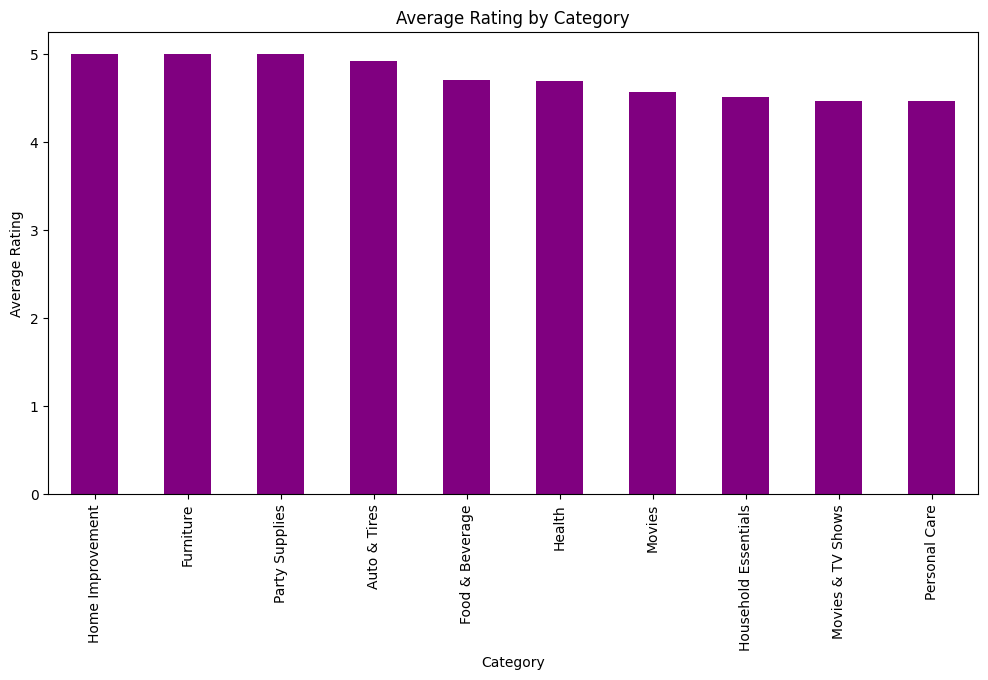

In [ ]:
plt.figure(figsize=(12,6))
category_ratings.head(10).plot(kind="bar",color="purple")
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.show()

Home Improvemnet, FUrniture, Party Supply recieve the highest average rating, but some of them only had 1 review. The lowest ratings come in at Holiday Shop, Pro Audio, and Gift Finder.

In [ ]:
#LEt's look closer
category_summary=(
    df_clean.groupby("first_category")["reviews.rating"]
    .agg(["count","mean"])
    .sort_values(by="count",ascending=False)
)

print(category_summary)

                          count      mean
first_category                           
Household Essentials       3796  4.512908
Movies                     2058  4.563654
Movies & TV Shows          1430  4.467832
Personal Care              1374  4.459971
Home                        468  4.326923
Food                        394  4.327411
School & Office Supplies    367  4.166213
Food & Beverage              43  4.697674
Household Chemicals          29  4.344828
Health                       13  4.692308
Auto & Tires                 12  4.916667
Sports & Outdoors             5  4.200000
Holiday Shop                  4  2.000000
Furniture                     1  5.000000
Home Improvement              1  5.000000
Gift Finder                   1  4.000000
Party Supplies                1  5.000000
Pro Audio                     1  3.000000


<Figure size 1200x600 with 0 Axes>

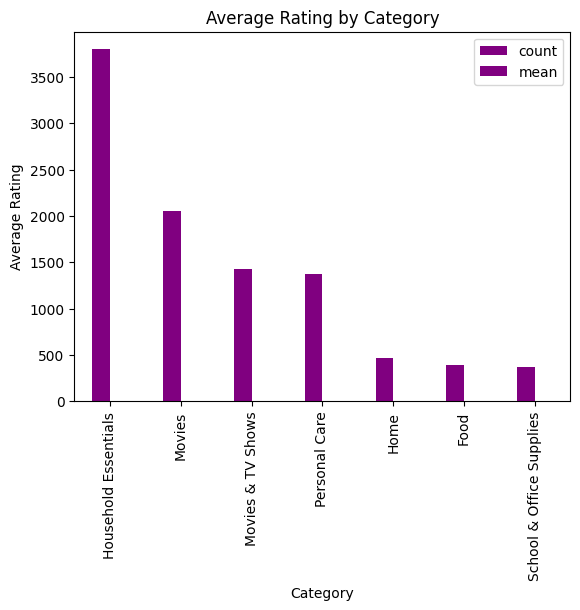

In [ ]:
#LET's clean up the graph make it neater. >:)
#Remove the categories with less than 100 reviews
category_summary=(
    df_clean.groupby("first_category")["reviews.rating"]
    .agg(["count","mean"])
  )
category_summary=category_summary[category_summary["count"]>100]
category_summary=category_summary.sort_values(by="count",ascending=False)

plt.figure(figsize=(12,6))
category_summary.head(10).plot(kind="bar",color="purple")
plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.show()

Shows Highest categories with 100 reviews or more.

In [ ]:
#Decision tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix)
import pandas as pd

# Ensure df_model has the 'cleaned_review' column before TF-IDF vectorization
# The clean_text function was defined earlier, so we can re-apply it to df_model
# This ensures that X and y are derived from the same filtered dataset (df_model)
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Make sure stopwords and wordnet are downloaded for the clean_text function
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
  text = str(text).lower()
  text = re.sub(r'\[.*?\]', '', text)
  text = re.sub(r'https?://\S+|www\.\S+', '', text)
  text = re.sub(r'<.*?>+', '', text)
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = re.sub(r'\n', '', text)
  text = re.sub(r'\w*\d\w*', '', text)
  words = text.split()
  words = [w for w in words if w not in stop_words]
  words = [lemmatizer.lemmatize(word, pos='a') for word in words]
  words = [lemmatizer.lemmatize(word, pos='v') for word in words]
  return " ".join(words)

df_model["cleaned_review"] = df_model["reviews.text"].apply(clean_text)

# Re-initialize TFidfVectorizer and transform only df_model's cleaned reviews
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=1000) # Use the same parameters as before
X = vectorizer.fit_transform(df_model["cleaned_review"])

#target
y=df_model["fake_review"]

#split data and keep class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#make decison tree
decision_tree= DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
decision_tree.fit(X_train,y_train)
#make predictions
dt_predictions=decision_tree.predict(X_test)
#evaluate the model
accuracy=accuracy_score(y_test,dt_predictions)
#print classification report
print(classification_report(y_test,dt_predictions))
print(
    classification_report(
        y_test,
        dt_predictions,
        target_names=["Real Review","Fake Review"],
        zero_division=0
    )
)
#print confusion matrix
print("confusion Matrix:")
print(confusion_matrix(y_test,dt_predictions))

              precision    recall  f1-score   support

           0       0.21      0.81      0.33        89
           1       0.97      0.63      0.76       760

    accuracy                           0.65       849
   macro avg       0.59      0.72      0.55       849
weighted avg       0.89      0.65      0.72       849

              precision    recall  f1-score   support

 Real Review       0.21      0.81      0.33        89
 Fake Review       0.97      0.63      0.76       760

    accuracy                           0.65       849
   macro avg       0.59      0.72      0.55       849
weighted avg       0.89      0.65      0.72       849

confusion Matrix:
[[ 72  17]
 [279 481]]


In [ ]:
dt_accuracy=accuracy_score(y_test,dt_predictions)
dt_precision=precision_score(y_test,dt_predictions)
dt_recall=recall_score(y_test,dt_predictions)
dt_f1=f1_score(y_test,dt_predictions)
#create summary table
dt_summary=pd.DataFrame({
    "Model":["Decision Tree"],
    "Accuracy":[dt_accuracy],
    "Precision":[dt_precision],
    "Recall":[dt_recall],
    "F1 Score":[dt_f1]
})

model_comparison=dt_summary
display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.6514,0.9659,0.6329,0.7647


In [ ]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier
#Create random forest model
rf_model=RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
#train the model
rf_model.fit(X_train,y_train)
#make predictions
rf_predicition=rf_model.predict(X_test)
#evaluate the model
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
print(classification_report(
    y_test,
    rf_predicition,
    target_names=["Real Review", "Fake Review"],
    zero_division=0
))

#Make summary metrics
import pandas as pd
rf_summary=pd.DataFrame({
    "Model":["Random Forest"],
    "Accuracy":[accuracy_score(y_test,rf_predicition)],
    "Precision":[precision_score(y_test,rf_predicition,pos_label=1)],
    "Recall":[recall_score(y_test,rf_predicition,pos_label=1)],
    "F1 Score":[f1_score(y_test,rf_predicition,pos_label=1)]
})
rf_summary=rf_summary.round(4)
display(rf_summary)

              precision    recall  f1-score   support

 Real Review       0.50      0.46      0.48        89
 Fake Review       0.94      0.95      0.94       760

    accuracy                           0.90       849
   macro avg       0.72      0.70      0.71       849
weighted avg       0.89      0.90      0.89       849



,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.8952,0.9374,0.9461,0.9417


In [ ]:
# Create Logistic Regression Summary
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Re-initialize and train Logistic Regression model (consistent with RF/DT data split)
# X_train, y_train, X_test, y_test are already defined from the DT/RF section (cell h5wH0r98Jp9Y)
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)

# Calculate metrics for logistic regression
log_accuracy = accuracy_score(y_test, logistic_predictions)
# Use pos_label=1 for 'Fake Review' to be consistent with rf_summary
log_precision = precision_score(y_test, logistic_predictions, pos_label=1, zero_division=0)
log_recall = recall_score(y_test, logistic_predictions, pos_label=1, zero_division=0)
log_f1 = f1_score(y_test, logistic_predictions, pos_label=1, zero_division=0)
#
logistic_summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [log_accuracy],
    "Precision": [log_precision],
    "Recall": [log_recall],
    "F1 Score": [log_f1]
})
logistic_summary = logistic_summary.round(4)
display(logistic_summary)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8504,0.9648,0.8645,0.9119


In [ ]:
#3 Deep Learning & NLP Review Analysis
# Detect Fake Reviews
#Let's Get the data together for deep learning
deep_df=df_model[
    ["reviews.text", "fake_review"]
].copy()
#Remove missing/empty review text
deep_df["reviews.text"]=(deep_df["reviews.text"]
    .astype(str)
    .str.strip())
deep_df=deep_df[deep_df["reviews.text"]!=""].copy()
deep_df["fake_review"]=deep_df["fake_review"].astype(int)
print(deep_df.shape)
print(deep_df["fake_review"].value_counts())

(4244, 2)
fake_review
1    3798
0     446
Name: count, dtype: int64


In [ ]:
#Build RNN to detect the fake reviews
#import RNN libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import(
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#Split the text and labels
X=deep_df["reviews.text"]
y=deep_df["fake_review"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training reviews:",len(x_train))
print("Test reviews:",len(x_test))

print("\nTraining labels")
print(y_train.value_counts())

print("\nTest labels")
print(y_test.value_counts())

Training reviews: 3395
Test reviews: 849

Training labels
fake_review
1    3038
0     357
Name: count, dtype: int64

Test labels
fake_review
1    760
0     89
Name: count, dtype: int64


In [ ]:
#Tokenizing the reviews
vocabulary_size=1000
maximum_length=150

rnn_tokenizer= Tokenizer(num_words=vocabulary_size)
rnn_tokenizer.fit_on_texts(x_train)

#LEarn vocabulary from the traiing data
rnn_tokenizer.fit_on_texts(x_train)

#Convert text to sequences
x_train_sequences=rnn_tokenizer.texts_to_sequences(x_train)
x_test_sequences=rnn_tokenizer.texts_to_sequences(x_test)
#Make the sequences the same length
maxlen=maximum_length
x_train_padded=pad_sequences(x_train_sequences,maxlen=maxlen)
x_test_padded=pad_sequences(x_test_sequences,maxlen=maxlen)
print("x_train_padded shape:",x_train_padded.shape)
print("x_test_padded shape:",x_test_padded.shape)

x_train_padded shape: (3395, 150)
x_test_padded shape: (849, 150)


 3,395 reviews in training, 849 in testing.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
vocabulary_size=10000
rnnmodel=Sequential([
    Embedding(vocabulary_size,64,input_length=maxlen),
    SimpleRNN(64),
    Dense(64,activation="relu"),
    Dropout(0.5),
    Dense(1,activation="sigmoid")
])

rnnmodel.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
rnnmodel.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(x_train_padded.shape)
print(x_train_padded.dtype)

(3395, 150)
int32


3395 review trainings, 150 reviews are tokens after padding to make the reviews the same length, so I could run Tensor FLow. Padding turned the words into numeric values.

In [ ]:
from tensorflow.keras.models  import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras import Input # Correctly import Input

vocabulary_size=10000
maximum_length=150

rnn_model=Sequential([
    Input(shape=(150,)),

    Embedding(
        input_dim= 10000,
        output_dim=128,
        mask_zero=True
    ),

    SimpleRNN(
        64,
        dropout=0.3,
        recurrent_dropout=0.2
    ),

    Dense(64,activation="relu"),
    Dropout(0.5),
    Dense(1,activation="sigmoid")
])
rnn_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)
rnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,296,577 (4.95 MB)

 Trainable params: 1,296,577 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Calculate the weights because we have imbalanced data.
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

classes=np.unique(y_train)
class_weights=compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weights={
    int(label):float(weight)
    for label, weight in zip(classes,class_weights)
}
print(class_weights)

{0: 4.754901960784314, 1: 0.5587557603686636}


This should make 0 become more important, to fix the imbalance.

In [ ]:
#Train the RNN
from tensorflow.keras.callbacks import EarlyStopping

early_stopping=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
history=rnn_model.fit(
    x_train_padded,
    y_train,
    validation_data=(x_test_padded,y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 22s 136ms/step - accuracy: 0.5638 - loss: 0.7063 - val_accuracy: 0.6490 - val_loss: 0.6675
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.6082 - loss: 0.6858 - val_accuracy: 0.8057 - val_loss: 0.5909
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.6966 - loss: 0.6014 - val_accuracy: 0.8433 - val_loss: 0.3414
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.7290 - loss: 0.5440 - val_accuracy: 0.8269 - val_loss: 0.3742
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.7888 - loss: 0.4884 - val_accuracy: 0.8292 - val_loss: 0.4039
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.8174 - loss: 0.4382 - val_accuracy: 0.8398 - val_loss: 0.4199


THis is ok despite some overfitting towards the end, the model started to train instead of recognizing the patterns, which is great. :)

In [ ]:
#test the RNN
from sklearn.metrics import classification_report, accuracy_score
y_probability= rnn_model.predict(x_test_padded).ravel()
y_pred=(y_probability>0.5).astype(int)
print(classification_report(y_test,y_pred, target_names=["Real Review","Possible Fake Review"], zero_division=0))
print(accuracy_score(y_test,y_pred))

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
                      precision    recall  f1-score   support

         Real Review       0.37      0.69      0.48        89
Possible Fake Review       0.96      0.86      0.91       760

            accuracy                           0.84       849
           macro avg       0.66      0.77      0.69       849
        weighted avg       0.90      0.84      0.86       849

0.8433451118963486


NOW this model is now VERY BIAS towards fake REVIEWS.

In [ ]:
print(deep_df.shape)
print(deep_df["fake_review"].value_counts())

(4244, 2)
fake_review
1    3798
0     446
Name: count, dtype: int64


In [ ]:
#Train BERT for fake review classification
#!pip install -q transformers datasets accelerate evaluate
!pip uninstall -y peft transformers accelerate datasets evaluate
!pip install -q torch torchvision torchaudio datasets accelerate evaluate
!pip install -q transformers==4.41.2 datasets==2.19.2 accelerate==0.31.0 evaluate==0.4.2



Found existing installation: transformers 4.41.2
Uninstalling transformers-4.41.2:
  Successfully uninstalled transformers-4.41.2
Found existing installation: accelerate 0.31.0
Uninstalling accelerate-0.31.0:
  Successfully uninstalled accelerate-0.31.0
Found existing installation: datasets 5.0.0
Uninstalling datasets-5.0.0:
  Successfully uninstalled datasets-5.0.0
Found existing installation: evaluate 0.4.6
Uninstalling evaluate-0.4.6:
  Successfully uninstalled evaluate-0.4.6


In [ ]:
import transformers
import torch
import datasets
import evaluate
import accelerate


print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)
print("Evaluate version:", evaluate.__version__)
print("Accelerate version:", accelerate.__version__)
print("PyTorch:",torch.__version__)

from transformers import Trainer
print("Trainer import successful")

Transformers version: 4.41.2
Datasets version: 2.19.2
Evaluate version: 0.4.2
Accelerate version: 0.31.0
PyTorch: 2.11.0+cpu
Trainer import successful


In [ ]:
import pandas as pd

#Load dataset for BERT and make the proxy target
file_path=(
    "/content/"
    "Data- Sentiment Analysis and Fake Review Detection in E-commerce.xlsx"
)
df=pd.read_excel("Data- Sentiment Analysis and Fake Review Detection in E-commerce.xlsx")

#Keep reviews with text and helpful vote
bert_df=df[["reviews.text","reviews.numHelpful"]].copy()
#turn helpful votes into numeric values
bert_df["reviews.numHelpful"]=pd.to_numeric(
    bert_df["reviews.numHelpful"],
    errors="coerce"
)
bert_df= bert_df.dropna(
    subset=["reviews.numHelpful"]
).copy()

#Clean empty text
bert_df["text"]=bert_df["reviews.text"].astype(str).str.strip()
bert_df=bert_df[
    bert_df["text"] !=""
].copy()

#Proxy classisfier
#1= no helpful votes or possible fakes
#0= at least one helpful vote/ possible real
bert_df["Label"]=(
    bert_df["reviews.numHelpful"]==0
).astype(int)

bert_df=bert_df[["text","Label"]]

print("dataset shape", bert_df.shape)
print("\nClass distribution:")
print(bert_df["Label"].value_counts())
print("\nClass percentages:")
print(bert_df["Label"].value_counts(normalize=True)*100)

dataset shape (4244, 2)

Class distribution:
Label
1    3798
0     446
Name: count, dtype: int64

Class percentages:
Label
1    89.491046
0    10.508954
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

#Bert SPlit test training
bert_train_df, bert_test_df = train_test_split(
    bert_df,
    test_size=0.2,
    random_state=42,
    stratify=bert_df["Label"]
)
print("Training shape:",bert_train_df.shape)
print("Testing shape:",bert_test_df.shape)

print("\nTraining labels")
print(bert_train_df["Label"].value_counts())
print("\nTesting labels")
print(bert_test_df["Label"].value_counts())

# Removed lines related to train_dataset and test_dataset as they are defined later and caused errors.

Training shape: (3395, 2)
Testing shape: (849, 2)

Training labels
Label
1    3038
0     357
Name: count, dtype: int64

Testing labels
Label
1    760
0     89
Name: count, dtype: int64


In [ ]:
from datasets import Dataset

#Convert Pandas to Hugging Face
train_dataset= Dataset.from_pandas(
    bert_train_df,
    preserve_index=False
)
test_dataset= Dataset.from_pandas(
    bert_test_df,
    preserve_index=False
)

print(train_dataset)
print(test_dataset)

Dataset({
    features: ['text', 'Label'],
    num_rows: 3395
})
Dataset({
    features: ['text', 'Label'],
    num_rows: 849
})


In [ ]:
from transformers import AutoTokenizer

#Tokenize the reviews
bert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_reviews(batch):
  return bert_tokenizer(
      batch["text"], # Corrected input to tokenize the 'text' column
      truncation=True,
      max_length=96
  )

train_dataset=train_dataset.map(
    tokenize_reviews,
    batched=True)
test_dataset=test_dataset.map(
    tokenize_reviews,
    batched=True)

print(train_dataset.column_names)
print(test_dataset.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/3395 [00:00<?, ? examples/s]

Map:   0%|          | 0/849 [00:00<?, ? examples/s]

['text', 'Label', 'input_ids', 'attention_mask']
['text', 'Label', 'input_ids', 'attention_mask']


In [ ]:
#Data Collator
from transformers import DataCollatorWithPadding

data_collator=DataCollatorWithPadding(
    tokenizer=bert_tokenizer
)

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
id2label={
    0:"Real Review",
    1:"Possible Fake Review"
}
label2id={
    "Real Review":0,
    "Possible Fake Review":1
}
bert_model=AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)
print("bert_model loaded correctly!!!")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


bert_model loaded correctly!!!


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
  logits, labels=eval_pred
  predictions=np.argmax(logits,axis=-1)
  accuracy=accuracy_score(labels,predictions)
  precision, recall, f1, _=precision_recall_fscore_support(
      labels,
      predictions,
      average="weighted",
      zero_division=0
  )
  return {
      "accuracy":accuracy,
      "precision":precision,
      "recall":recall,
      "f1":f1
  }

In [ ]:
from transformers import TrainingArguments
training_args=TrainingArguments(
    output_dir="./distilbert_fake_reviews",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=25,
    report_to="none",
    use_cpu=True,
    seed=42
)




In [ ]:
training_dataset = (
    train_dataset
    .shuffle(seed=42)
    .select(range(min(1000, train_dataset.num_rows)))
)
evaluation_dataset = (
    train_dataset
    .shuffle(seed=42)
    .select(range(min(300, test_dataset.num_rows)))
)
print("Training samples used:",training_dataset.num_rows)
print("Evaluation samples used:",evaluation_dataset.num_rows)

Training samples used: 1000
Evaluation samples used: 300


In [ ]:
#Check to see if they're on there correctly
print("bert_model:","bert_model" in globals())
print("training_args:","training_args" in globals())
print("data_collator:","data_collator" in globals())
print("compute_metrics:","compute_metrics" in globals())
print("training_dataset:","training_dataset" in globals())
print("evaluation_dataset:","evaluation_dataset" in globals())

bert_model: True
training_args: True
data_collator: True
compute_metrics: True
training_dataset: True
evaluation_dataset: True


Every varible is installed correctly 😃

In [ ]:
#now lets do this. TRAINER
from transformers import Trainer
trainer=Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=training_dataset,
    eval_dataset=evaluation_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


In [ ]:
from transformers import Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=evaluation_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.231800,0.213378,0.906667,0.868881,0.906667,0.876391
2,0.205600,0.182611,0.926667,0.915235,0.926667,0.914750
3,0.150200,0.164950,0.946667,0.942191,0.946667,0.942414


TrainOutput(global_step=639, training_loss=0.20733901517865058, metrics={'train_runtime': 4415.4548, 'train_samples_per_second': 2.307, 'train_steps_per_second': 0.145, 'total_flos': 204928876798548.0, 'train_loss': 0.20733901517865058, 'epoch': 3.0})

In [ ]:
import pandas as pd

#Logistic regression
logistc_summary=pd.DataFrame({
    "Model":["Logistic Regression"],
    "Accuracy":[0.8866],
    "Precision":[0.980],
    "Recall":[0.8900],
    "F1 Score":[0.938] # Changed 'F1-Score' to 'F1 Score'
})
#Decision Tree
decision_tree_summary=pd.DataFrame({
    "Model":["Decision Tree"],
    "Accuracy":[0.6514],
    "Precision":[0.9659],
    "Recall":[0.6329],
    "F1 Score":[0.7647] # Changed 'F1-Score' to 'F1 Score'
})
#Random Forest
random_forest_summary=pd.DataFrame({
    "Model":["Random Forest"],
    "Accuracy":[0.8952],
    "Precision":[0.9374],
    "Recall":[0.9461],
    "F1 Score":[0.9417]
})
#BERT
bert_summary=pd.DataFrame({
    "Model":["BERT"],
    "Accuracy":[0.9467],
    "Precision":[0.9422],
    "Recall":[0.9467],
    "F1 Score":[0.9424]
})
#Concatenate all the models
model_summary=pd.concat([
    logistc_summary,
    decision_tree_summary,
    rf_summary,
    bert_summary
],ignore_index=True)
print(model_summary.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.8866     0.9800  0.8900    0.9380
1        Decision Tree    0.6514     0.9659  0.6329    0.7647
2        Random Forest    0.8952     0.9374  0.9461    0.9417
3                 BERT    0.9467     0.9422  0.9467    0.9424


In [ ]:
#GRADIO SETUP
#!pip install -q gradio transformers sentencepiece huggingface_hub
!pip uninstall -y transformers tokenizers huggingface_hub fsspec gcsfs numpy rich
!pip install -q \
  --upgrade \
  "numpy==2.1" \
  "fsspec==2025.3.0" \
  "gcsfs==2025.3.0" \
  "rich<14" \
  "jedi>=0.16" \
  "huggingface_hub>=1.2.0,<2.0" \
  "transformers==5.13.1" \
  "tokenizers==0.22.2" \
  "gradio==6.20.0" \
  "diffusers==0.39.0" \
  sentencepiece \
  safetensors

Found existing installation: transformers 5.13.1
Uninstalling transformers-5.13.1:
  Successfully uninstalled transformers-5.13.1
Found existing installation: tokenizers 0.22.2
Uninstalling tokenizers-0.22.2:
  Successfully uninstalled tokenizers-0.22.2
Found existing installation: huggingface_hub 1.23.0
Uninstalling huggingface_hub-1.23.0:
  Successfully uninstalled huggingface_hub-1.23.0
Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0
Found existing installation: gcsfs 2025.3.0
Uninstalling gcsfs-2025.3.0:
  Successfully uninstalled gcsfs-2025.3.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: rich 13.9.4
Uninstalling rich-13.9.4:
  Successfully uninstalled rich-13.9.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 47.9 MB/s eta 0:00:00
   

In [ ]:
!pip install -q--force-reinstall "numpy==2.0.2"


Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --


In [ ]:
!pip install numpy==2.0.2

In [ ]:
import numpy as np
import numba

print("Numpy:",np.__version__)
print("Numba:",numba.__version__)

Numpy: 2.0.2
Numba: 0.60.0


In [ ]:
#checking for more problems
!pip check

ipython 7.34.0 requires jedi, which is not installed.


In [ ]:
!pip install jedi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.8 MB/s eta 0:00:00


In [ ]:
!pip check

No broken requirements found.


GREAT GRADIO IS RUNNING NOW!

In [ ]:
import pandas as pd
file_path="/content/Data- Sentiment Analysis and Fake Review Detection in E-commerce.xlsx"
df=pd.read_excel(file_path)
#keep rows that contain usable review text
df_reviews=df.dropna(subset=["reviews.text"]).copy()

df_reviews["reviews.text"]=(
    df_reviews["reviews.text"]
    .astype(str)
    .str.strip()
)
df_reviews=df_reviews[df_reviews["reviews.text"]!=""]
print("Total usable reviews:", len(df_reviews))

Total usable reviews: 9998


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Define model and tokenizer
model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model.generation_config.forced_bos_token_id = 0

# Define summarize_text function
def summarize_text(text):
  text = str(text).strip()
  if not text:
    return ""
  inputs = tokenizer(
      text,
      max_length=1024,
      truncation=True,
      return_tensors="pt"
  )
  summary_ids = model.generate(
      **inputs,
      max_length=80,
      min_length=15,
      num_beams=4,
      do_sample=False,
      early_stopping=True
  )
  return tokenizer.decode(
      summary_ids[0],
      skip_special_tokens=True
  )

# Define summarize_review_collection function
def summarize_review_collection(reviews, reviews_per_batch=10):
    all_summaries = []
    for i in range(0, len(reviews), reviews_per_batch):
        batch = reviews[i:i + reviews_per_batch]
        combined_batch_text = " ".join([r.strip() for r in batch if r.strip()])
        if combined_batch_text:
            batch_summary = summarize_text(combined_batch_text)
            all_summaries.append(batch_summary)
    if all_summaries:
        final_summary = summarize_text(" ".join(all_summaries))
        return final_summary
    return "No reviews provided for summarization."

test_reviews = (
    df_reviews["reviews.text"]
    .sample(n=50, random_state=42)
    .tolist()
)
test_summary=summarize_review_collection(
    test_reviews,
    reviews_per_batch=10
)
print("Sumaary of 50 random reviews:")
print(test_summary)

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.22GB            

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.22GB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Sumaary of 50 random reviews:
 Maybe not Depp's best film, but great price and still Depp . Unbelievable price for 5 BluRay movies and a digital copy of one of the five as well in a nice collectors box . The upright is lightweight and powerful; works just as well on bare floor as on carpet .


In [ ]:
import gradio as gr
def gradio_review_summarizer(selected_brand,number_of_reviews):
  number_of_reviews=int(number_of_reviews)

  #Filter the reviews by their brand
  if selected_brand == "ALL Brands":
    selected_reviews = df_reviews["reviews.text"]
  else:
    selected_reviews = df_reviews.loc[
        df_reviews["brand"].astype(str) == selected_brand,
        "reviews.text"
    ]
  #Clean the review text
  selected_reviews = selected_reviews.dropna()
  selected_reviews = selected_reviews.astype(str).str.strip()
  selected_reviews=selected_reviews[selected_reviews != ""]
  total_available= len(selected_reviews)

  if total_available == 0:
    return "No reviews found.", "Reviews used: 0"
  #Prevent requesting more reviews than there are avaiable
  number_to_use=min(number_of_reviews,total_available)
  selected_reviews=selected_reviews.sample(
      n=number_to_use
    ).tolist()

  summary=summarize_review_collection(
      selected_reviews,
      reviews_per_batch=10
  )
  details = (
      f"Brand: {selected_brand}\n"
      f"Reviews available: {total_available:,}\n"
      f"Random reviews summarized: {number_to_use:,}"
  )
  return summary, details

In [ ]:
import gradio as gr
import pandas as pd # Import pandas here as well

# Load dataset for Gradio interface and prepare df_reviews
file_path="/content/Data- Sentiment Analysis and Fake Review Detection in E-commerce.xlsx"
df=pd.read_excel(file_path)
# keep rows that contain usable review text
df_reviews=df.dropna(subset=["reviews.text"]).copy()

df_reviews["reviews.text"]=(df_reviews["reviews.text"].astype(str).str.strip())
df_reviews=df_reviews[df_reviews["reviews.text"]!=""]

#creat dropdown choices
brand_options=sorted(
    df_reviews["brand"]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)

brand_options = ["ALL Brands"] + brand_options

def gradio_review_summarizer(selected_brand, number_of_reviews):
  number_of_reviews = int(number_of_reviews)

  # Filter the reviews by their brand
  if selected_brand == "ALL Brands":
    selected_reviews = df_reviews["reviews.text"]
  else:
    selected_reviews = df_reviews.loc[
        df_reviews["brand"].astype(str) == selected_brand,
        "reviews.text"
    ]
  #Clean the reviews
  selected_reviews = selected_reviews.dropna()
  selected_reviews = selected_reviews.astype(str).str.strip()
  selected_reviews = selected_reviews[selected_reviews != ""]
  total_available = len(selected_reviews)

  if total_available == 0:
    return "No reviews found.", "Reviews used: 0"

  # Prevent requesting more reviews than available
  number_to_use = min(number_of_reviews, total_available)
  selected_reviews = selected_reviews.sample(n=number_to_use).tolist()

  #Make a summary
  summary = summarize_review_collection(selected_reviews, reviews_per_batch=10)
  details = (
      f"Brand: {selected_brand}\n"
      f"Reviews available: {total_available:,}\n"
      f"Random reviews summarized: {number_to_use:,}"
  )
  return summary, details

demo = gr.Interface(
    fn=gradio_review_summarizer,
    inputs=[
        gr.Dropdown(
            label="Select Brand",
            choices=brand_options,
            value="Clorox"
        ),
        gr.Slider(
            minimum=1,
            maximum=50,
            value=10,
            step=1,
            label="Number of Reviews to Summarize"
        )
    ],
    outputs=[
        gr.Textbox(
            label="Customer Review Summary",
            lines=10
        ),
        gr.Textbox(
            label="Details"
        )
    ],
    title="E-commerce Customer Review Summarizer",
    description=(
        "Select a brand and choose how many random reviews to summarize.\n"
        "The application pulls the reviews directly from the Excel spreedsheet."
    )
)

demo.launch(
  share=True,
  debug=True
)

NameError: name 'df_reviews' is not defined